# E-Ticaret Müşteri Davranışları Analizi

In [19]:
import pandas as pd
import numpy as np

#  manuel veri oluşturulması
veri = {
    'Musteri_ID': range(1, 11),
    'Yas': [25, 34, np.nan, 45, 23, 50, 31, np.nan, 40, 29], # 2 adet eksik veri (NaN)
    'Aylik_Gelir_TL': [50000, 75000, 60000, 120000, 45000, 150000, 80000, 55000, 2500000, 62000], # 2.5 Milyon TL aykırı değer!
    'Harcama_Skoru': [60, 85, 45, 90, 30, 95, 70, 50, 20, 65], # 1-100 arası bir skor
    'Sehir': ['Istanbul', 'Ankara', 'Izmir', 'Istanbul', 'Bursa', 'Ankara', 'Istanbul', 'Izmir', 'Ankara', 'Bursa'],
    'Premium_Uye': [True, True, False, True, False, True, False, False, True, False]
}

df = pd.DataFrame(veri)
print("Veri Seti Başarıyla Oluşturuldu!")

Veri Seti Başarıyla Oluşturuldu!


In [20]:
df

,Musteri_ID,Yas,Aylik_Gelir_TL,Harcama_Skoru,Sehir,Premium_Uye
0,1,25.0,50000,60,Istanbul,True
1,2,34.0,75000,85,Ankara,True
2,3,NaN,60000,45,Izmir,False
3,4,45.0,120000,90,Istanbul,True
4,5,23.0,45000,30,Bursa,False
5,6,50.0,150000,95,Ankara,True
6,7,31.0,80000,70,Istanbul,False
7,8,NaN,55000,50,Izmir,False
8,9,40.0,2500000,20,Ankara,True
9,10,29.0,62000,65,Bursa,False


<Axes: >

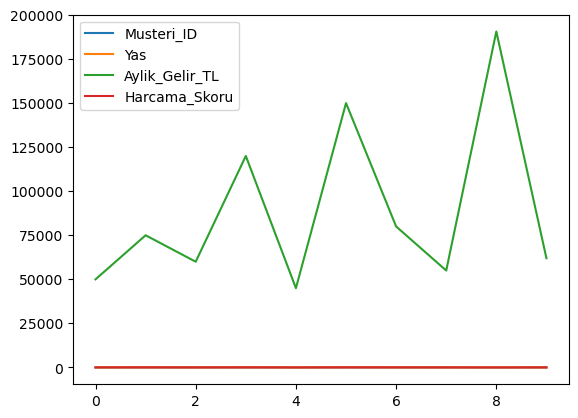

In [33]:
df.plot()

In [ ]:
print("--- 1. İlk 3 Satır yazdır ---")
print(df.head(3))

print("\n--- 2. Veri Setinin Boyutunu yazdır (shape) ---")
print(f"Satır Sayısı: {df.shape[0]}, Sütun Sayısı: {df.shape[1]}")


In [21]:
max_indeks = df['Aylik_Gelir_TL'].idxmax()
min_indeks = df['Aylik_Gelir_TL'].idxmin()
print(max_indeks)
print(min_indeks)
print(df.loc[4,'Sehir'])

8
4
Bursa


In [22]:
# aylık geliri en yüksek olan müşteri ile en düşük olan müşterinin yaşadığı şehileri bulalım.
print("\n--- idxmax() ve idxmin() İndeks Yakalayıcılar ile sehri Bulma  ---")
# Mantık: idxmax() doğrudan maksimum değerin bulunduğu satırın indeks numarasını (sırasını) verir.
max_indeks = df['Aylik_Gelir_TL'].idxmax()
min_indeks = df['Aylik_Gelir_TL'].idxmin()

# loc[] ile o indeksteki şehrin adını çekeriz
en_yuksek_sehir_2 = df.loc[max_indeks, 'Sehir']
en_dusuk_sehir_2 = df.loc[min_indeks, 'Sehir']

print(f"En Yüksek Gelirli Müşterinin Şehri: {en_yuksek_sehir_2}")
print(f"En Düşük Gelirli Müşterinin Şehri:  {en_dusuk_sehir_2}")


--- idxmax() ve idxmin() İndeks Yakalayıcılar ile sehri Bulma  ---
En Yüksek Gelirli Müşterinin Şehri: Ankara
En Düşük Gelirli Müşterinin Şehri:  Bursa


In [23]:
print("\n--- 4. Yas sutunundaki eksik verilerileri  medyan yaş ile dolduralım ---")


# Basit bir çözüm simülasyonu: Eksik yaşları, medyan yaş ile dolduralım
medyan_yas = df['Yas'].median()
df['Yas'] = df['Yas'].fillna(medyan_yas)
print(f"\nEksik yaş bilgileri, medyan değer olan {medyan_yas} ile dolduruldu.")
df


--- 4. Yas sutunundaki eksik verilerileri  medyan yaş ile dolduralım ---

Eksik yaş bilgileri, medyan değer olan 32.5 ile dolduruldu.


,Musteri_ID,Yas,Aylik_Gelir_TL,Harcama_Skoru,Sehir,Premium_Uye
0,1,25.0,50000,60,Istanbul,True
1,2,34.0,75000,85,Ankara,True
2,3,32.5,60000,45,Izmir,False
3,4,45.0,120000,90,Istanbul,True
4,5,23.0,45000,30,Bursa,False
5,6,50.0,150000,95,Ankara,True
6,7,31.0,80000,70,Istanbul,False
7,8,32.5,55000,50,Izmir,False
8,9,40.0,2500000,20,Ankara,True
9,10,29.0,62000,65,Bursa,False


In [24]:
print("---  Aylık gelirdeki aykırı değeri IQR Yöntemi ile Aykırı Değer (Outlier) Analizi ---")
print("---  Aykırı değerler üst ve alt limit ile doldurulacak ---")


# 1. IQR ve Sınırların Hesaplanması
Q1 = df['Aylik_Gelir_TL'].quantile(0.25)
Q3 = df['Aylik_Gelir_TL'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR
print(' Alt sınır', alt_sinir)
print(' Üst sınır', ust_sinir)
print(f"Baskılama için Üst Sınır: {ust_sinir} TL")

# Görselleştirme için orijinal veriyi saklayalım
orijinal_gelir = df['Aylik_Gelir_TL'].copy()

# Baskılama (Capping) İşlemi - Pandas clip() fonksiyonu
df['Aylik_Gelir_TL'] = df['Aylik_Gelir_TL'].clip(lower=alt_sinir, upper=ust_sinir)

print("\n--- Baskılama Sonrası Veri Seti (İlk 10 Satır) ---")
print(df[['Musteri_ID', 'Aylik_Gelir_TL']])
orijinal_gelir

---  Aylık gelirdeki aykırı değeri IQR Yöntemi ile Aykırı Değer (Outlier) Analizi ---
---  Aykırı değerler üst ve alt limit ile doldurulacak ---
 Alt sınır -24375.0
 Üst sınır 190625.0
Baskılama için Üst Sınır: 190625.0 TL

--- Baskılama Sonrası Veri Seti (İlk 10 Satır) ---
   Musteri_ID  Aylik_Gelir_TL
0           1           50000
1           2           75000
2           3           60000
3           4          120000
4           5           45000
5           6          150000
6           7           80000
7           8           55000
8           9          190625
9          10           62000


0      50000
1      75000
2      60000
3     120000
4      45000
5     150000
6      80000
7      55000
8    2500000
9      62000
Name: Aylik_Gelir_TL, dtype: int64

In [25]:
print("\n--- 6. Şehirlere Göre Müşteri Dağılımı (value_counts) ---")
print(df['Sehir'].value_counts())




--- 6. Şehirlere Göre Müşteri Dağılımı (value_counts) ---
Sehir
Istanbul    3
Ankara      3
Izmir       2
Bursa       2
Name: count, dtype: int64


In [26]:
print("\n--- 7. Premium Üyeliğe Göre Ortalama Harcama Skoru (groupby) ---")
grup_ozeti = df.groupby('Premium_Uye')['Harcama_Skoru'].mean()
print(grup_ozeti)


--- 7. Premium Üyeliğe Göre Ortalama Harcama Skoru (groupby) ---
Premium_Uye
False    52.0
True     70.0
Name: Harcama_Skoru, dtype: float64


In [27]:
print("\n--- 8.  Sehirlere göre Aylık Ortalama gelir  (groupby) ---")
grup_ozeti = df.groupby('Sehir')['Aylik_Gelir_TL'].mean()
print(grup_ozeti)


--- 8.  Sehirlere göre Aylık Ortalama gelir  (groupby) ---
Sehir
Ankara      138541.666667
Bursa        53500.000000
Istanbul     83333.333333
Izmir        57500.000000
Name: Aylik_Gelir_TL, dtype: float64


In [ ]:
print("\n--- 9.  Sehirlere göre  max aylık gelir (groupby) ---")
grup_ozeti = df.groupby('Sehir')['Aylik_Gelir_TL'].max()
print(grup_ozeti)


--- 8.  Sehirlere göre   (groupby) ---
Sehir
Ankara      190625
Bursa        62000
Istanbul    120000
Izmir        60000
Name: Aylik_Gelir_TL, dtype: int64
